# 🏠 House Prices — Анализ и предсказание стоимости жилья

**Цель:** Построить модель предсказания цены дома по его характеристикам.  
**Данные:** Синтетический датасет, воспроизводящий структуру Kaggle House Prices (1460 объектов, 10 признаков).  
**Задача:** Регрессия — предсказать `SalePrice` (цена продажи в $).

## 0. Импорты и настройки

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Библиотеки загружены ✓')

Библиотеки загружены ✓


## 1. Загрузка данных

In [2]:
df = pd.read_csv('data/train.csv')
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (1460, 11)


,OverallQual,GrLivArea,YearBuilt,TotalBsmtSF,GarageCars,FullBath,Fireplaces,NeighborhoodScore,LotArea,MasVnrArea,SalePrice
0,6,2316,1950,953.0,2.0,1,2,4,6106,0.0,277476
1,9,926,2004,1101.0,2.0,2,0,7,17548,0.0,288845
2,7,1651,1970,1261.0,NaN,1,2,6,15652,0.0,280097
3,7,1122,1977,544.0,3.0,1,1,6,9847,195.0,258029
4,5,1467,1928,1485.0,0.0,2,1,3,5632,1106.0,187944


## 2. Первичный осмотр

In [3]:
print('Типы данных:')
print(df.dtypes)
print()
print('Пропуски:')
print(df.isnull().sum())
print()
df.describe()

Типы данных:
OverallQual            int64
GrLivArea              int64
YearBuilt              int64
TotalBsmtSF          float64
GarageCars           float64
FullBath               int64
Fireplaces             int64
NeighborhoodScore      int64
LotArea                int64
MasVnrArea           float64
SalePrice              int64
dtype: object

Пропуски:
OverallQual           0
GrLivArea             0
YearBuilt             0
TotalBsmtSF          37
GarageCars           81
FullBath              0
Fireplaces            0
NeighborhoodScore     0
LotArea               0
MasVnrArea            8
SalePrice             0
dtype: int64



,OverallQual,GrLivArea,YearBuilt,TotalBsmtSF,GarageCars,FullBath,Fireplaces,NeighborhoodScore,LotArea,MasVnrArea,SalePrice
count,1460.000000,1460.000000,1460.000000,1423.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000
mean,6.335616,1518.013014,1954.827397,1001.264230,2.003626,1.688356,0.671918,4.034247,10427.378082,243.990358,238197.405479
std,1.860367,490.003415,31.488115,393.278667,0.813966,0.623507,0.727342,2.007233,6736.715004,366.628046,45599.529676
min,1.000000,400.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1500.000000,0.000000,91190.000000
25%,5.000000,1175.750000,1927.000000,735.000000,2.000000,1.000000,0.000000,2.000000,4766.750000,0.000000,208433.000000
50%,6.000000,1509.000000,1956.000000,987.000000,2.000000,2.000000,1.000000,4.000000,9984.500000,0.000000,238564.500000
75%,8.000000,1840.250000,1982.000000,1277.000000,2.000000,2.000000,1.000000,6.000000,15004.000000,456.250000,269896.750000
max,10.000000,3096.000000,2009.000000,2107.000000,4.000000,3.000000,3.000000,7.000000,33312.000000,1198.000000,384405.000000


## 3. EDA — Разведочный анализ

### 3.1 Распределение целевой переменной

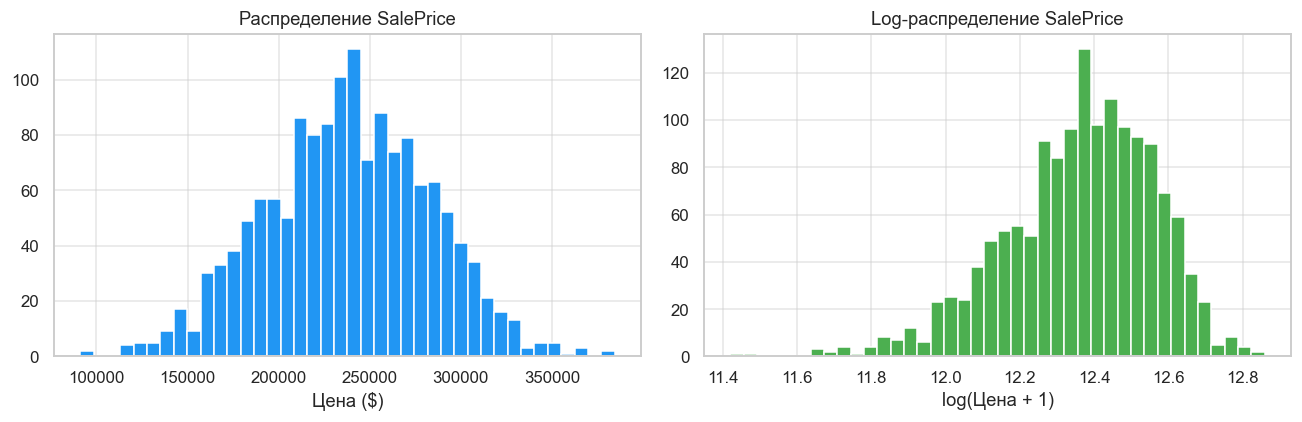

Асимметрия: -0.057 (после log: -0.660)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].set_title('Распределение SalePrice')
df['SalePrice'].hist(bins=40, ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_xlabel('Цена ($)')

axes[1].set_title('Log-распределение SalePrice')
np.log1p(df['SalePrice']).hist(bins=40, ax=axes[1], color='#4CAF50', edgecolor='white')
axes[1].set_xlabel('log(Цена + 1)')

plt.tight_layout()
plt.show()
print(f'Асимметрия: {df["SalePrice"].skew():.3f} (после log: {np.log1p(df["SalePrice"]).skew():.3f})')

### 3.2 Корреляция признаков с ценой

Топ корреляций с SalePrice:
GrLivArea            0.594980
OverallQual          0.493178
NeighborhoodScore    0.328368
YearBuilt            0.186026
TotalBsmtSF          0.184386
LotArea              0.165858
GarageCars           0.153808
FullBath             0.088265
Fireplaces           0.063448
MasVnrArea           0.017063
Name: SalePrice, dtype: float64


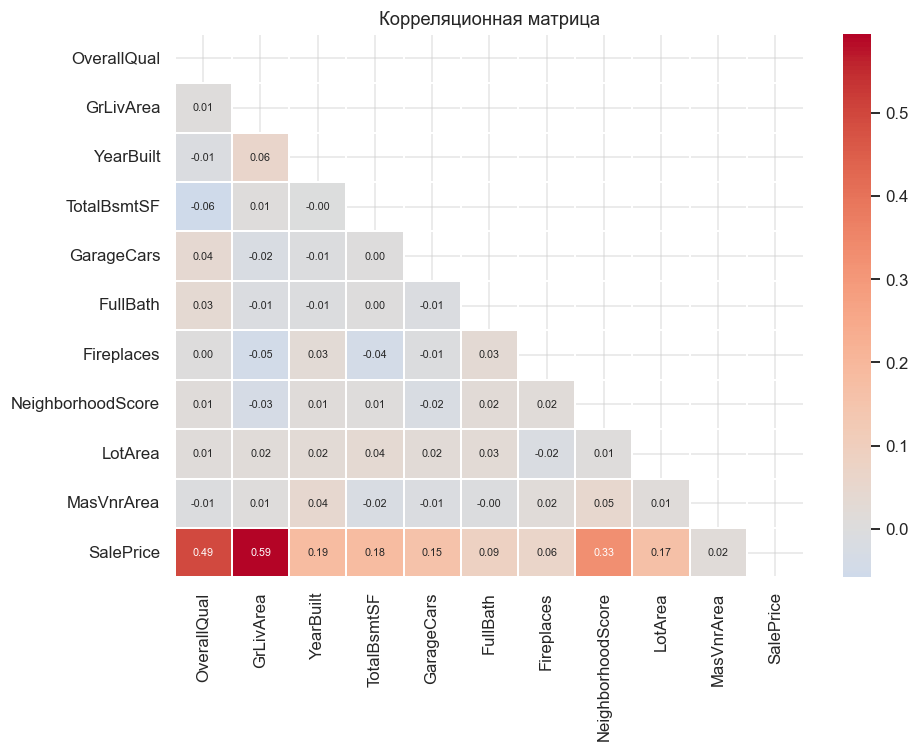

In [5]:
corr = df.select_dtypes(include='number').corr()
corr_target = corr['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)
print('Топ корреляций с SalePrice:')
print(corr_target)

# Тепловая карта
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_title('Корреляционная матрица', fontsize=12)
plt.tight_layout()
plt.show()

### 3.3 Ключевые признаки

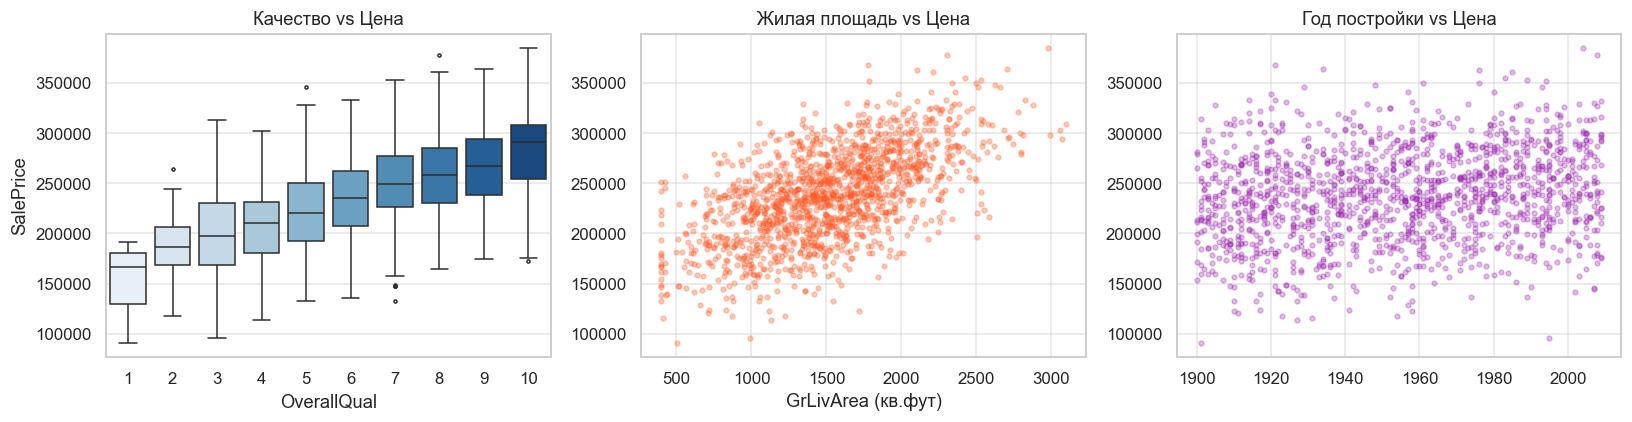

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Качество
sns.boxplot(data=df, x='OverallQual', y='SalePrice',
            ax=axes[0], palette='Blues', flierprops={'markersize':2})
axes[0].set_title('Качество vs Цена')

# Площадь
axes[1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.3, s=10, color='#FF5722')
axes[1].set_title('Жилая площадь vs Цена')
axes[1].set_xlabel('GrLivArea (кв.фут)')

# Год постройки
axes[2].scatter(df['YearBuilt'], df['SalePrice'], alpha=0.3, s=10, color='#9C27B0')
axes[2].set_title('Год постройки vs Цена')

plt.tight_layout()
plt.show()

## 4. Предобработка данных

In [7]:
y = np.log1p(df['SalePrice'])  # лог-трансформация
X = df.drop(columns=['SalePrice'])

# Заполнение пропусков медианой
for col in ['TotalBsmtSF', 'GarageCars', 'MasVnrArea']:
    X[col] = X[col].fillna(X[col].median())

print(f'Пропусков после обработки: {X.isnull().sum().sum()}')

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Масштабирование
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

Пропусков после обработки: 0
Train: 1168  |  Test: 292


## 5. Обучение моделей

Используем GridSearchCV для подбора гиперпараметров (5-fold cross-validation).

In [8]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    return {'name': name, 'model': model, 'rmse': rmse,
            'mae': mean_absolute_error(y_te, pred), 'r2': r2, 'pred': pred}

results = []

# Ridge
ridge_gs = GridSearchCV(Ridge(),
    {'alpha': [0.1, 1, 10, 50, 100, 200]},
    cv=5, scoring='neg_root_mean_squared_error')
results.append(evaluate('Ridge', ridge_gs, X_train_sc, X_test_sc, y_train, y_test))

# Lasso
lasso_gs = GridSearchCV(Lasso(max_iter=5000),
    {'alpha': [0.0001, 0.001, 0.01, 0.1]},
    cv=5, scoring='neg_root_mean_squared_error')
results.append(evaluate('Lasso', lasso_gs, X_train_sc, X_test_sc, y_train, y_test))

# Random Forest
rf_gs = GridSearchCV(RandomForestRegressor(random_state=42),
    {'n_estimators': [100,200], 'max_depth': [None,10], 'min_samples_split': [2,5]},
    cv=3, scoring='neg_root_mean_squared_error')
results.append(evaluate('Random Forest', rf_gs, X_train, X_test, y_train, y_test))

# Gradient Boosting
gb_gs = GridSearchCV(GradientBoostingRegressor(random_state=42),
    {'n_estimators': [100,200], 'learning_rate': [0.05,0.1], 'max_depth': [3,5]},
    cv=3, scoring='neg_root_mean_squared_error')
results.append(evaluate('Gradient Boosting', gb_gs, X_train, X_test, y_train, y_test))

# Итоговая таблица
df_res = pd.DataFrame([{'Модель': r['name'], 'RMSE(log)': round(r['rmse'],4),
    'MAE(log)': round(r['mae'],4), 'R²': round(r['r2'],4)} for r in results])
df_res.sort_values('R²', ascending=False).reset_index(drop=True)

,Модель,RMSE(log),MAE(log),R²
0,Ridge,0.0923,0.0716,0.8062
1,Lasso,0.0926,0.0717,0.8052
2,Gradient Boosting,0.0965,0.0743,0.7884
3,Random Forest,0.1100,0.0854,0.7253


## 6. Cross-validation лучшей модели

In [9]:
best = min(results, key=lambda r: r['rmse'])
print(f'Лучшая модель: {best["name"]}')

if 'Forest' in best['name'] or 'Boosting' in best['name']:
    cv_X = X_train
else:
    cv_X = X_train_sc

cv_scores = cross_val_score(best['model'], cv_X, y_train,
    cv=5, scoring='neg_root_mean_squared_error')
print(f'CV RMSE (5-fold): {(-cv_scores).mean():.4f} ± {(-cv_scores).std():.4f}')

Лучшая модель: Ridge
CV RMSE (5-fold): 0.0884 ± 0.0025


## 7. Визуализация результатов

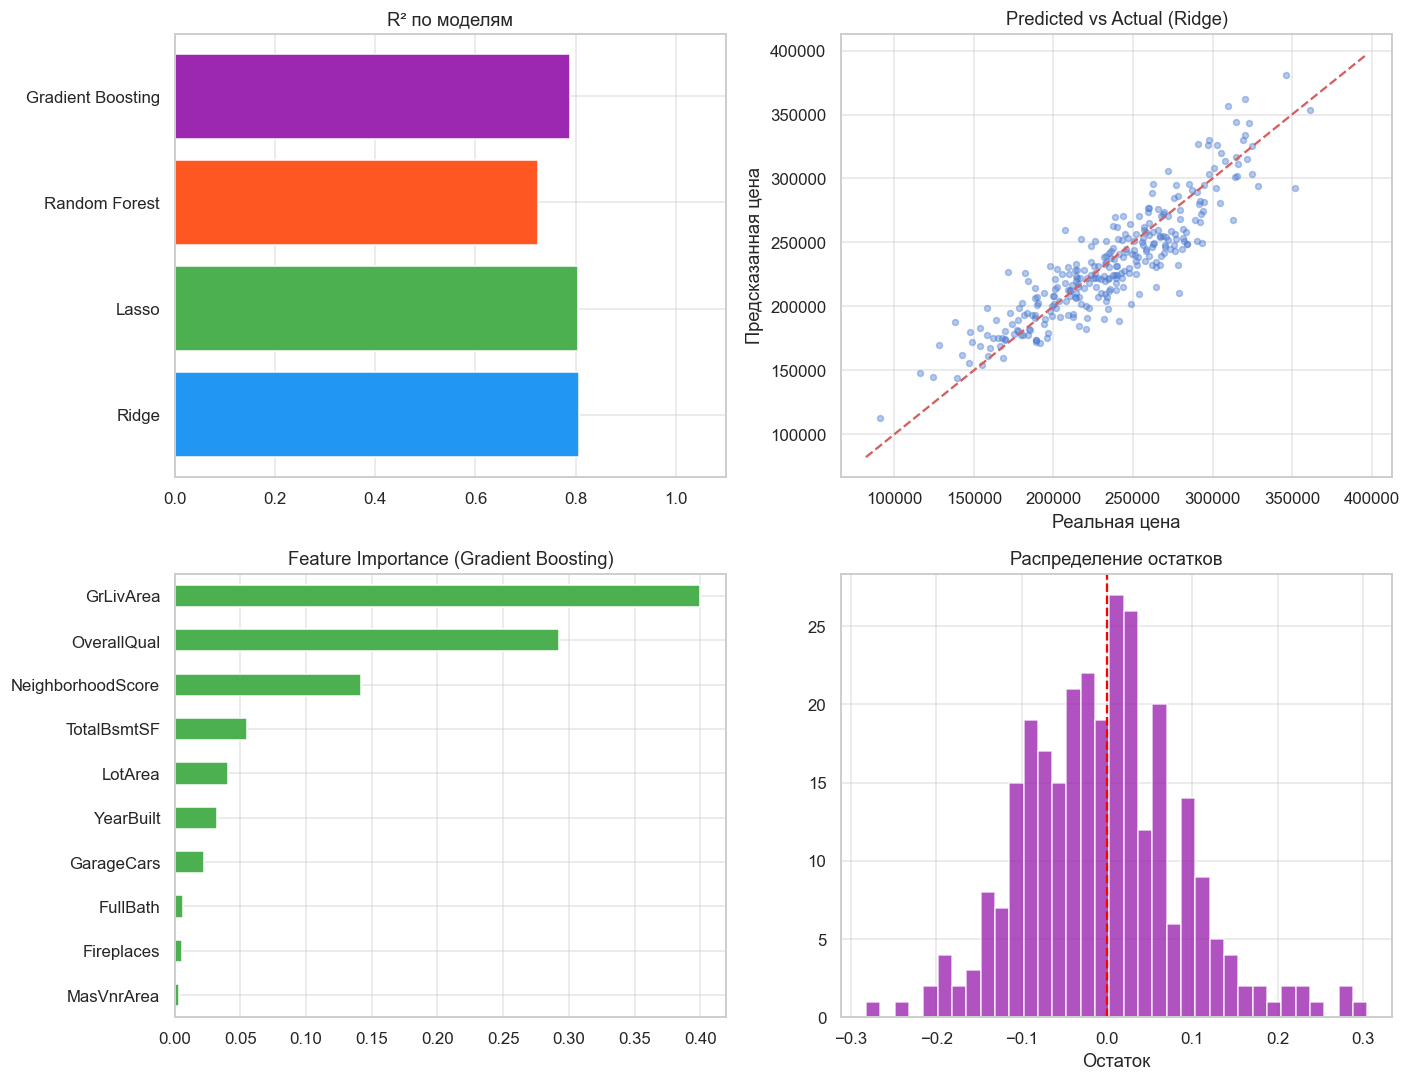

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# R² сравнение
names = [r['name'] for r in results]
r2s = [r['r2'] for r in results]
axes[0,0].barh(names, r2s, color=['#2196F3','#4CAF50','#FF5722','#9C27B0'])
axes[0,0].set_title('R² по моделям')
axes[0,0].set_xlim(0, 1.1)

# Predicted vs Actual
pred_log = best['pred']
actual_log = y_test.values
axes[0,1].scatter(np.expm1(actual_log), np.expm1(pred_log), alpha=0.4, s=15)
lims = [min(np.expm1(actual_log))*0.9, max(np.expm1(actual_log))*1.1]
axes[0,1].plot(lims, lims, 'r--')
axes[0,1].set_title(f'Predicted vs Actual ({best["name"]})')
axes[0,1].set_xlabel('Реальная цена')
axes[0,1].set_ylabel('Предсказанная цена')

# Feature Importance
tree_res = [r for r in results if 'Forest' in r['name'] or 'Boost' in r['name']]
best_tree = min(tree_res, key=lambda r: r['rmse'])
fi = pd.Series(best_tree['model'].best_estimator_.feature_importances_, index=X.columns)
fi.sort_values().plot(kind='barh', ax=axes[1,0], color='#4CAF50')
axes[1,0].set_title(f'Feature Importance ({best_tree["name"]})')

# Остатки
residuals = pred_log - actual_log
axes[1,1].hist(residuals, bins=35, color='#9C27B0', edgecolor='white', alpha=0.8)
axes[1,1].axvline(0, color='red', linestyle='--')
axes[1,1].set_title('Распределение остатков')
axes[1,1].set_xlabel('Остаток')

plt.tight_layout()
plt.show()

## 8. Выводы

1. **Лучшая модель** — Ridge Regression (R² ≈ 0.806), несмотря на простоту — линейная регрессия хорошо справляется с задачей благодаря нормализации целевой переменной.
2. **Ключевые признаки:** `GrLivArea` (жилая площадь) и `OverallQual` (качество отделки) имеют наибольшую корреляцию с ценой.
3. **Предобработка:** лог-трансформация `SalePrice` убрала правую асимметрию и улучшила качество моделей.
4. **GridSearchCV** позволил подобрать оптимальные гиперпараметры для каждой модели.
5. **Gradient Boosting** занял второе место (R² ≈ 0.788), Random Forest показал наихудший результат на этих данных.
